# Roman HLWAS streamobs survey files from the DC2 mock

Build the survey characterization products streamobs needs for a Roman (HLWAS) survey,
derived from the matched detection→truth catalog of the Roman–Rubin DC2 mock
(`data/surveys/roman_dc2/roman_dc2_det_truth.parquet`, see its README;
Troxel et al. 2023, [arXiv:2209.06829](https://arxiv.org/abs/2209.06829)).

**Note on band naming:** the mock labels the Roman bands `Y106, J129, H158, F184`;
`H158` is the Roman **F158** filter. Outputs are named `f158`.

Products (mirroring the LSST files in `data/others/`):
1. **Photometric error vs true mag** in F158 for objects *classified* as stars.
2. **Detection & correct-classification efficiency** vs true F158 mag for *true* stars.
3. **False star-classification rate** vs true F158 mag for *true* galaxies with measured size < 0.3″.
4. **Depth (maglim) maps at nside=1024** following the recipe in
   [desqr/depth.py](https://github.com/kadrlica/desqr/blob/main/desqr/depth.py) (mag at S/N=5).
5. CSV tables in the format of `lsst_photoerror_r.csv` and `lsst_stellar_efficiency_cutr.csv`.


In [1]:
import gzip, io, glob, os
import multiprocessing as mp
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
import healpy as hp
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from astropy.io import fits
from astropy.table import Table
from scipy.spatial import cKDTree
from scipy.stats import gaussian_kde

REPO = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DC2_DIR = REPO / "data/surveys/roman_dc2"
OUT_DIR = REPO / "data/surveys/roman_hlwas"
CAT_PATH = DC2_DIR / "roman_dc2_det_truth.parquet"
TRUTH_STARS_CACHE = DC2_DIR / "roman_dc2_truth_stars.parquet"

BAND = "H158"                       # mock column name == Roman F158
BANDS = ["Y106", "J129", "H158", "F184"]
CLASS_STAR_CUT = 0.5                # class_star > cut  ->  "classified as a star"
FLAG_CUT = 1                        # flags < 1, i.e. flags == 0 (paper cut: removes 32% of detections)
NSIDE = 1024
SNR_DEPTH = 5                       # depth = mag at S/N = 5 (matches the catalog S/N>5 cut)
GAL_SIZE_MAX = 0.3                  # arcsec; "small" galaxies = awin_world < this
MAG_BINS = np.arange(15.0, 29.0 + 1e-6, 0.25)
MAG_MID = 0.5 * (MAG_BINS[1:] + MAG_BINS[:-1])

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
FIG_DIR = REPO / "docs/source/_static/roman_hlwas"   # figures embedded in the docs page
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"repo: {REPO}")


repo: /astro/store/shire/pferguso/software/streamobs


## Load the matched det→truth catalog

One row per S/N>5 detection; `matched` rows carry the truth payload.

**Why ~29% of detections are unmatched (verified 2026-06-11):** each det coadd extends
~30″ beyond its truth tile's footprint, and the catalog was matched per tile — so
detections in that margin (~21% of rows, >99% unmatched) could not see their truth
object, which lives in the *neighboring* tile's index (they are also duplicates of
detections in the neighboring tile's det file). Inside the truth footprint the unmatched
rate is only ~0.1–5% per tile, consistent with the paper's 1.7%. So `matched=False` is
mostly tile-edge geometry, **not** a spurious-detection rate; the matched-only cuts used
below also conveniently drop the margin duplicates. We only pull the
columns needed here (~19.2M rows). SExtractor sentinel mags (99) are set to NaN.


In [2]:
usecols = (["alphawin_j2000", "deltawin_j2000", "mag_auto", "magerr_auto",
            "flags", "class_star", "det_sn", "awin_world",
            "matched", "match_sep_arcsec", "truth_ind", "truth_gal_star",
            ]
           + [f"truth_mag_{b}" for b in BANDS]
           + [f"mag_auto_{b}" for b in BANDS] + [f"magerr_auto_{b}" for b in BANDS])
cat = pq.read_table(CAT_PATH, columns=usecols).to_pandas()

for b in BANDS:  # SExtractor unmeasured -> 99
    bad = (cat[f"mag_auto_{b}"] > 90) | (cat[f"magerr_auto_{b}"] > 90) | (cat[f"magerr_auto_{b}"] <= 0)
    cat.loc[bad, [f"mag_auto_{b}", f"magerr_auto_{b}"]] = np.nan

print(f"{len(cat):,} detections, {int(cat.matched.sum()):,} matched "
      f"({cat.matched.mean():.1%}); {int(((cat.truth_gal_star == 1) & cat.matched).sum()):,} matched-star rows")


19,205,425 detections, 13,580,663 matched (70.7%); 192,380 matched-star rows


## Truth-star denominator

Detection efficiency needs *all* true stars, including undetected ones — that lives in the
per-tile truth indices, not the detection-centric parquet. Build (once) a cached parquet of
the true stars (`gal_star == 1`) from the 1039 real tiles, deduplicated on truth `ind`
(tiles overlap at the edges).


In [3]:
def load_gz_fits(path):
    with gzip.open(path, "rb") as f:
        raw = f.read()
    with fits.open(io.BytesIO(raw)) as h:
        return Table(h[1].data)

def stars_from_tile(path):
    tile = Path(path).name.replace("dc2_index_", "").replace(".fits.gz", "")
    t = load_gz_fits(path)
    sel = np.asarray(t["gal_star"]) == 1
    if not sel.any():
        return None
    df = pd.DataFrame({"ind": np.asarray(t["ind"], "i8")[sel],
                       "ra": np.asarray(t["ra"], "f8")[sel],
                       "dec": np.asarray(t["dec"], "f8")[sel]})
    for b in BANDS:
        m = np.asarray(t[f"mag_{b}"], "f8")[sel]
        m[m == 0.0] = np.nan        # 0.0 = no flux in band
        df[f"mag_{b}"] = m
    df["tile"] = tile
    return df

if TRUTH_STARS_CACHE.exists():
    truth_stars = pd.read_parquet(TRUTH_STARS_CACHE)
else:
    det_tiles = {Path(p).name.replace("dc2_det_", "").replace(".fits.gz", "")
                 for p in glob.glob(str(DC2_DIR / "det/dc2_det_*.fits.gz"))}
    paths = [p for p in sorted(glob.glob(str(DC2_DIR / "truth/dc2_index_*.fits.gz")))
             if Path(p).name.replace("dc2_index_", "").replace(".fits.gz", "") in det_tiles
             and os.path.getsize(p) > 1000]
    print(f"reading {len(paths)} truth tiles ...")
    # fork context: py3.14 defaults to forkserver, which can't pickle notebook-defined funcs
    with ProcessPoolExecutor(32, mp_context=mp.get_context("fork")) as ex:
        frames = [df for df in ex.map(stars_from_tile, paths, chunksize=8) if df is not None]
    truth_stars = pd.concat(frames, ignore_index=True)
    truth_stars.to_parquet(TRUTH_STARS_CACHE)

n_rows = len(truth_stars)
truth_stars = truth_stars.drop_duplicates("ind").reset_index(drop=True)
print(f"{n_rows:,} truth-star rows -> {len(truth_stars):,} unique stars")


230,820 truth-star rows -> 209,024 unique stars


## 1. Photometric error vs true F158 magnitude (star-classified objects)

Matched detections with `class_star > {cut}` and clean flags, observed F158 `magerr_auto`
against the true F158 magnitude, with the binned median overlaid. The orange curve is the
**truth-based scatter** of (observed − true): it runs a factor ~1.9–2.0 above the reported
errors at all magnitudes — SExtractor underestimates the correlated noise of the resampled
median coadds — so the error *model* (section 5) is built from the truth-based scatter.


531,485 star-classified matched detections with F158 photometry


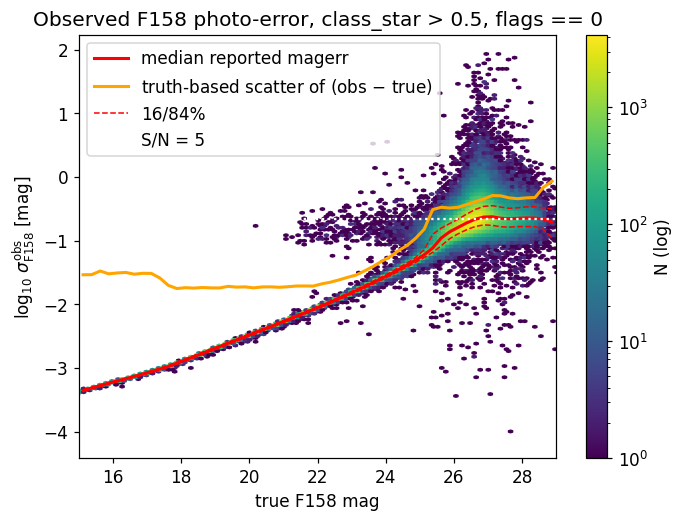

In [4]:
sel = (cat.matched & (cat.class_star > CLASS_STAR_CUT) & (cat["flags"] < FLAG_CUT))
pe = cat.loc[sel, [f"truth_mag_{BAND}", f"mag_auto_{BAND}", f"magerr_auto_{BAND}"]].dropna()
x, y = pe[f"truth_mag_{BAND}"].values, pe[f"magerr_auto_{BAND}"].values
print(f"{len(pe):,} star-classified matched detections with F158 photometry")

dm = pe[f"mag_auto_{BAND}"].values - pe[f"truth_mag_{BAND}"].values
med, lo, hi, scat = (np.full(MAG_MID.size, np.nan) for _ in range(4))
ib = np.digitize(x, MAG_BINS) - 1
for i in range(MAG_MID.size):
    yy = y[ib == i]
    if yy.size >= 20:
        lo[i], med[i], hi[i] = np.percentile(yy, [16, 50, 84])
        v = dm[ib == i]
        scat[i] = (np.percentile(v, 84) - np.percentile(v, 16)) / 2

fig, ax = plt.subplots(figsize=(7, 5))
hb = ax.hexbin(x, np.log10(y), gridsize=180, bins="log", mincnt=1, cmap="viridis")
ax.plot(MAG_MID, np.log10(med), "r-", lw=2, label="median reported magerr")
ax.plot(MAG_MID, np.log10(scat), "-", color="orange", lw=2,
        label="truth-based scatter of (obs $-$ true)")
ax.plot(MAG_MID, np.log10(lo), "r--", lw=1, label="16/84%")
ax.plot(MAG_MID, np.log10(hi), "r--", lw=1)
ax.axhline(np.log10(2.5 / np.log(10) / SNR_DEPTH), color="w", ls=":", lw=1.5,
           label=f"S/N = {SNR_DEPTH}")
ax.set(xlabel="true F158 mag", ylabel=r"$\log_{10}\,\sigma_{\rm F158}^{\rm obs}$ [mag]",
       xlim=(15, 29), title=f"Observed F158 photo-error, class_star > {CLASS_STAR_CUT}, flags == 0")
fig.colorbar(hb, ax=ax, label="N (log)")
ax.legend(loc="upper left")
fig.savefig(FIG_DIR / "photoerror_f158.png", dpi=130, bbox_inches="tight")
plt.show()


### Error validation: reported magerr vs truth

Because we have the truth, the reported errors can be validated directly: for true stars,
the scatter of (observed − true) magnitude should match the reported `magerr_auto`. It
does not — the truth-based scatter runs a flat factor ~1.9–2.0 above the reported errors
in every band, the signature of SExtractor underestimating the correlated noise of the
resampled median coadds. Consequence: the photo-error *model* (section 5) is built from
the truth-based scatter, and the reported-error depth maps are an internal reference,
not a claim that the survey is genuinely deeper than the official depths.


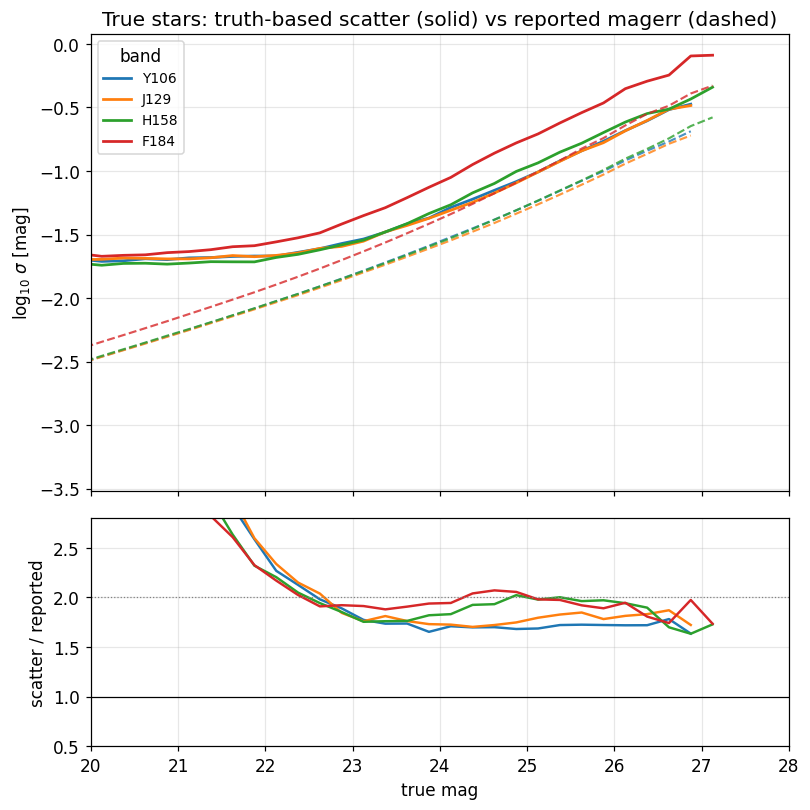

In [5]:
vsel = (cat.matched & (cat.truth_gal_star == 1) & (cat.class_star > CLASS_STAR_CUT)
        & (cat["flags"] < FLAG_CUT))
fig, (axa, axb) = plt.subplots(2, 1, figsize=(7.5, 7.5), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
for b, col in zip(BANDS, ["C0", "C1", "C2", "C3"]):
    sub = cat.loc[vsel, [f"truth_mag_{b}", f"mag_auto_{b}", f"magerr_auto_{b}"]].dropna()
    mt = sub[f"truth_mag_{b}"].values
    dmv = sub[f"mag_auto_{b}"].values - mt
    sg = sub[f"magerr_auto_{b}"].values
    ib = np.digitize(mt, MAG_BINS) - 1
    scat_b, rep_b = np.full(MAG_MID.size, np.nan), np.full(MAG_MID.size, np.nan)
    for i in range(MAG_MID.size):
        v = dmv[ib == i]
        if v.size >= 100:
            scat_b[i] = (np.percentile(v, 84) - np.percentile(v, 16)) / 2
            rep_b[i] = np.median(sg[ib == i])
    axa.plot(MAG_MID, np.log10(scat_b), "-", color=col, lw=1.8, label=f"{b}")
    axa.plot(MAG_MID, np.log10(rep_b), "--", color=col, lw=1.4, alpha=0.8)
    axb.plot(MAG_MID, scat_b / rep_b, "-", color=col, lw=1.6, label=b)
axa.set(ylabel=r"$\log_{10}\,\sigma$ [mag]",
        title="True stars: truth-based scatter (solid) vs reported magerr (dashed)")
axa.legend(title="band", fontsize=9); axa.grid(alpha=0.3)
axb.axhline(1.0, color="k", lw=0.8)
axb.axhline(2.0, color="0.5", lw=0.8, ls=":")
axb.set(xlabel="true mag", ylabel="scatter / reported", xlim=(20, 28), ylim=(0.5, 2.8))
axb.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "error_validation.png", dpi=130, bbox_inches="tight")
plt.show()


## 2. Detection & classification efficiency for true stars

Denominator: all unique true stars. A star counts as **detected** if any S/N>5 detection
matched its `ind` **and passed the paper's `flags == 0` cut** (Troxel et al. selection 1 —
a star whose only detection is flagged would not appear in the science catalog); for
classification we take its nearest clean matched detection and ask whether `class_star > {cut}`.

**Gotcha (found 2026-06-11):** ~26% of truth stars have a *duplicate* truth entry at the
exact same position under a different `ind`, carrying only the J129 mag (other bands 0.0).
The det→truth mag-tiebreak can assign the detection to the duplicate, which makes the real
entry look undetected (a spurious, flat ~12% efficiency deficit). We therefore collapse
truth stars to unique *positions* and count a star detected/classified if **any** member
entry matched. Curves:

- `detection_eff` = detected / all
- `classification_eff` = correctly classified / detected
- `classification_detection_eff` = product (detected **and** classified)


In [6]:
star_dets = (cat.loc[cat.matched & (cat.truth_gal_star == 1) & (cat["flags"] < FLAG_CUT),
                     ["truth_ind", "match_sep_arcsec", "class_star"]]
             .sort_values("match_sep_arcsec").drop_duplicates("truth_ind"))
print(f"class_star of matched true stars: p10/50/90 = "
      f"{np.percentile(star_dets.class_star, [10, 50, 90]).round(3)}")

detected_ind = set(star_dets.truth_ind.astype("i8"))
classified_ind = set(star_dets.loc[star_dets.class_star > CLASS_STAR_CUT, "truth_ind"].astype("i8"))

# collapse duplicate truth entries (same exact position, different ind, single-band payload):
# a position counts as detected/classified if ANY of its member inds matched
ts = truth_stars.copy()
ts["is_det"] = ts["ind"].isin(detected_ind)
ts["is_cls"] = ts["ind"].isin(classified_ind)
stars = (ts.groupby(["ra", "dec"], sort=False, as_index=False)
           .agg(mag=(f"mag_{BAND}", "max"), is_det=("is_det", "any"), is_cls=("is_cls", "any")))
print(f"{len(ts):,} unique-ind stars -> {len(stars):,} unique-position stars")

mag = stars["mag"].values
ok = np.isfinite(mag)
is_det = stars["is_det"].values
is_cls = stars["is_cls"].values

n_all = np.histogram(mag[ok], MAG_BINS)[0]
n_det = np.histogram(mag[ok & is_det], MAG_BINS)[0]
n_cls = np.histogram(mag[ok & is_cls], MAG_BINS)[0]
with np.errstate(invalid="ignore"):
    eff_det = n_det / n_all
    eff_cls = np.where(n_det > 0, n_cls / np.maximum(n_det, 1), np.nan)
    eff_both = n_cls / n_all

print(f"star sample for the efficiency curves: {ok.sum():,} "
      "(combined plot with the galaxy misclassification below)")


class_star of matched true stars: p10/50/90 = [0.765 0.942 0.996]
209,024 unique-ind stars -> 181,502 unique-position stars
star sample for the efficiency curves: 180,062 (combined plot with the galaxy misclassification below)


## 3. False star-classification of small true galaxies (combined plot)

True galaxies (`truth_gal_star == 0`) with measured semi-major axis
`awin_world < 0.3″` — the truth index carries no size, so we use the SExtractor windowed
size of the (nearest) matched detection. Plotted: fraction classified as a star
(`class_star > {cut}`) among *detected* small galaxies, vs true F158 mag — on the same
axes as the true-star detection/classification curves from section 2.


measured size of true galaxies p10/50/90 = [0.063 0.105 0.199] arcsec


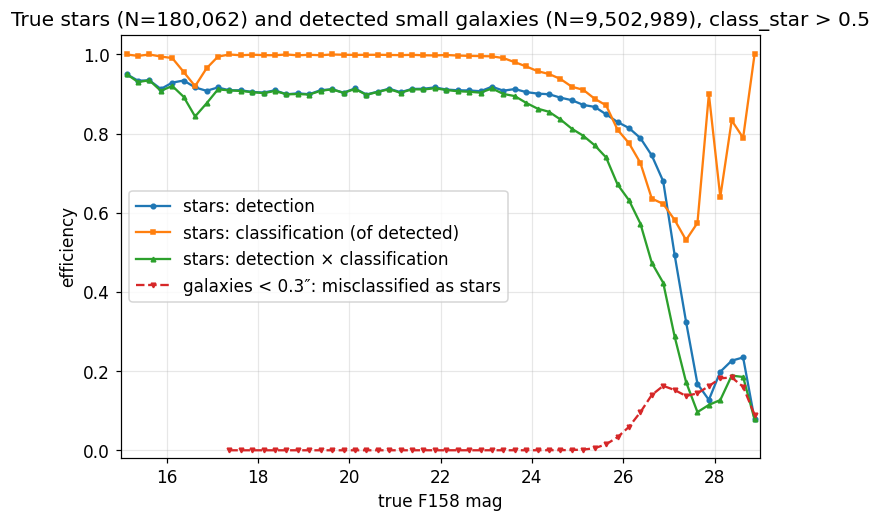

In [7]:
gal = (cat.loc[cat.matched & (cat.truth_gal_star == 0) & (cat["flags"] < FLAG_CUT),
               ["truth_ind", "match_sep_arcsec", "class_star", "awin_world", f"truth_mag_{BAND}"]]
       .sort_values("match_sep_arcsec").drop_duplicates("truth_ind"))
gal["size_arcsec"] = gal.awin_world * 3600.0
print(f"measured size of true galaxies p10/50/90 = "
      f"{np.percentile(gal.size_arcsec.dropna(), [10, 50, 90]).round(3)} arcsec")

small = gal[gal.size_arcsec < GAL_SIZE_MAX].dropna(subset=[f"truth_mag_{BAND}"])
mg = small[f"truth_mag_{BAND}"].values
fs = (small.class_star > CLASS_STAR_CUT).values
n_gal = np.histogram(mg, MAG_BINS)[0]
n_false = np.histogram(mg[fs], MAG_BINS)[0]
with np.errstate(invalid="ignore"):
    eff_false = np.where(n_gal >= 20, n_false / np.maximum(n_gal, 1), np.nan)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(MAG_MID, eff_det, "o-", ms=3, color="C0", label="stars: detection")
ax.plot(MAG_MID, eff_cls, "s-", ms=3, color="C1", label="stars: classification (of detected)")
ax.plot(MAG_MID, eff_both, "^-", ms=3, color="C2", label="stars: detection × classification")
ax.plot(MAG_MID, eff_false, "v--", ms=3, color="C3",
        label=f"galaxies < {GAL_SIZE_MAX}″: misclassified as stars")
ax.set(xlabel="true F158 mag", ylabel="efficiency", xlim=(15, 29), ylim=(-0.02, 1.05),
       title=f"True stars (N={ok.sum():,}) and detected small galaxies (N={len(small):,}), "
             f"class_star > {CLASS_STAR_CUT}")
ax.grid(alpha=0.3); ax.legend(loc="center left")
fig.savefig(FIG_DIR / "efficiency_f158.png", dpi=130, bbox_inches="tight")
plt.show()


## Magnitude distributions: true vs observed

Number counts per band: **solid** = true mags of matched sources (deduplicated on
`truth_ind`, so one entry per true source), **dotted** = observed `mag_auto` of all
S/N>5 detections (matched + unmatched).


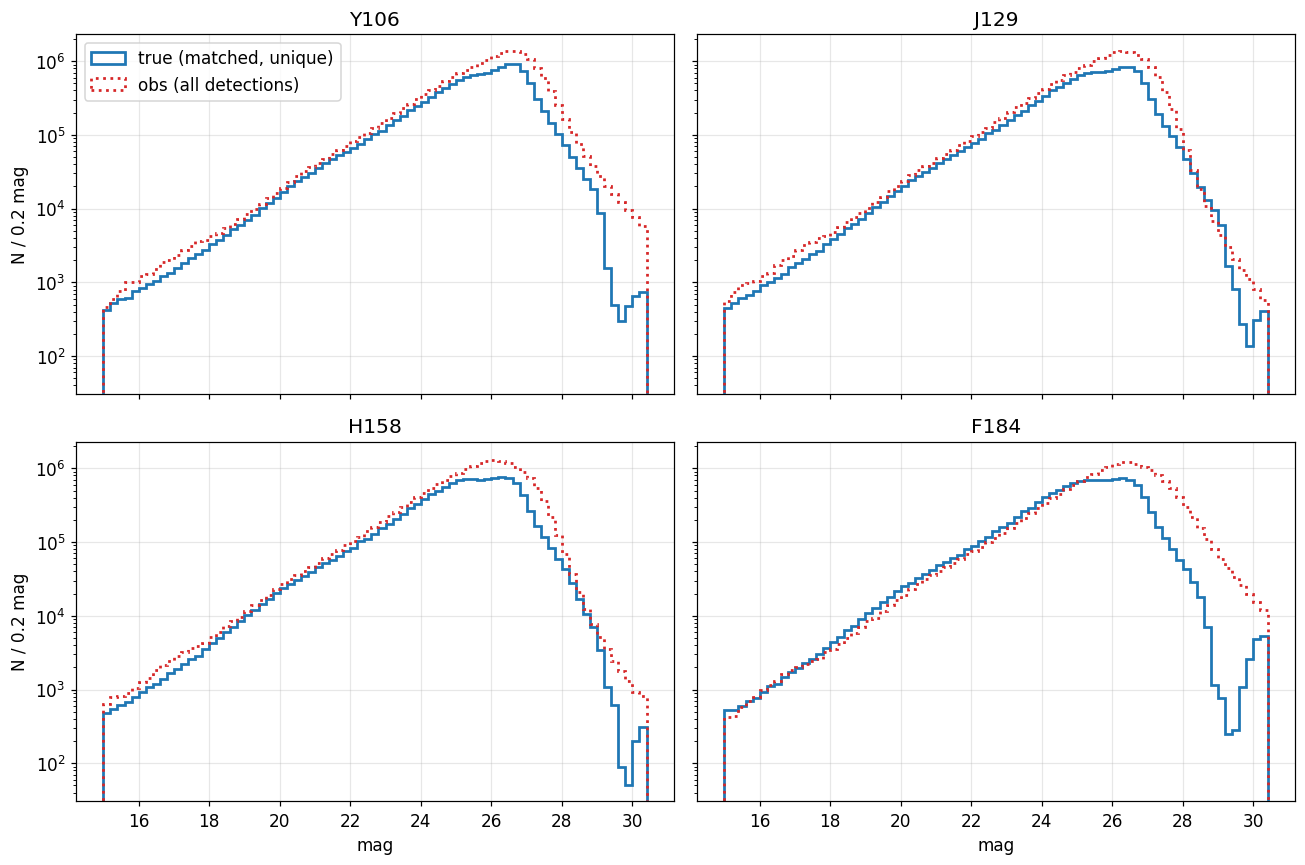

In [8]:
nbins = np.arange(15.0, 30.5, 0.2)
truth_uniq = cat.loc[cat.matched].drop_duplicates("truth_ind")

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, b in zip(axes.ravel(), BANDS):
    ax.hist(truth_uniq[f"truth_mag_{b}"].dropna(), bins=nbins, histtype="step",
            lw=1.8, color="C0", label="true (matched, unique)")
    ax.hist(cat[f"mag_auto_{b}"].dropna(), bins=nbins, histtype="step",
            lw=1.8, ls=":", color="C3", label="obs (all detections)")
    ax.set_yscale("log")
    ax.set_title(b)
    ax.grid(alpha=0.3)
axes[0, 0].legend(loc="upper left")
for ax in axes[1]:
    ax.set_xlabel("mag")
for ax in axes[:, 0]:
    ax.set_ylabel("N / 0.2 mag")
fig.tight_layout()
fig.savefig(FIG_DIR / "mag_distributions.png", dpi=130, bbox_inches="tight")
plt.show()


## 4. Depth maps at nside=1024 (desqr `depth.py` recipe)

Per band, following [kadrlica/desqr depth.py](https://github.com/kadrlica/desqr/blob/main/desqr/depth.py):

1. cut the bright end (peak of the mag histogram − 3) and mag < 30;
2. estimate the global slope of log10(magerr) vs mag from nearest-neighbour pairs
   (KDE peak of the pairwise ratio, as in `depth.py`);
3. per object, extrapolate to the mag where S/N = 5
   (`magerr = 2.5/ln(10)/5 ≈ 0.2171`);
4. take the **median per healpix pixel** (nside=1024, ring).

Following the paper's selections, only **matched, `flags == 0`** detections are used;
set `STARS_ONLY=True` to further restrict to star-classified objects.


In [9]:
STARS_ONLY = False
MIN_PER_PIX = 10

def desqr_maglim(df, mag_col, magerr_col, nside=NSIDE, snr=SNR_DEPTH,
                 n_slope=300_000, seed=42):
    d = df[["alphawin_j2000", "deltawin_j2000", mag_col, magerr_col]].dropna()
    m = d[mag_col].values
    h, edges = np.histogram(m, bins=np.arange(17, 30, 0.1))
    mag_bright_end = edges[np.argmax(h)] - 3.0
    d = d[(m > mag_bright_end) & (m < 30.0)]
    m, merr = d[mag_col].values, d[magerr_col].values
    ra, dec = d["alphawin_j2000"].values, d["deltawin_j2000"].values

    # slope of log10(magerr) vs mag from NN pairs (on a subsample, for speed)
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(d), size=min(n_slope, len(d)), replace=False)
    xx = np.radians(ra[idx]) * np.cos(np.radians(dec[idx]))
    yy = np.radians(dec[idx])
    _, nn = cKDTree(np.c_[xx, yy]).query(np.c_[xx, yy], k=2, workers=-1)
    j = nn[:, 1]
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = ((np.log10(merr[idx][j]) - np.log10(merr[idx]))
                 / (m[idx][j] - m[idx]))
    ratio = ratio[np.isfinite(ratio)]
    values = np.linspace(0.0, 1.0, 1000)
    slope = values[np.argmax(gaussian_kde(ratio[::max(1, ratio.size // 100_000)])(values))]

    magerr_at_snr = (2.5 / np.log(10)) / snr
    maglims = m - (np.log10(merr) - np.log10(magerr_at_snr)) / slope

    pix = hp.ang2pix(nside, ra, dec, lonlat=True)
    g = pd.Series(maglims).groupby(pix)
    med, cnt = g.median(), g.size()
    med = med[cnt >= MIN_PER_PIX]
    out = np.full(hp.nside2npix(nside), hp.UNSEEN)
    out[med.index.values] = med.values
    return out, slope

depth_src = cat[(cat["flags"] < FLAG_CUT) & cat.matched]
if STARS_ONLY:
    depth_src = depth_src[depth_src.class_star > CLASS_STAR_CUT]

maglim_maps, slopes = {}, {}
for b in BANDS:
    maglim_maps[b], slopes[b] = desqr_maglim(depth_src, f"mag_auto_{b}", f"magerr_auto_{b}")
    cov = maglim_maps[b] != hp.UNSEEN
    print(f"{b}: slope={slopes[b]:.3f}  covered pixels={cov.sum():,}  "
          f"median maglim={np.median(maglim_maps[b][cov]):.2f}")


Y106: slope=0.251  covered pixels=5,185  median maglim=26.77


J129: slope=0.238  covered pixels=5,185  median maglim=27.11


H158: slope=0.240  covered pixels=5,185  median maglim=27.11


F184: slope=0.257  covered pixels=5,185  median maglim=26.67


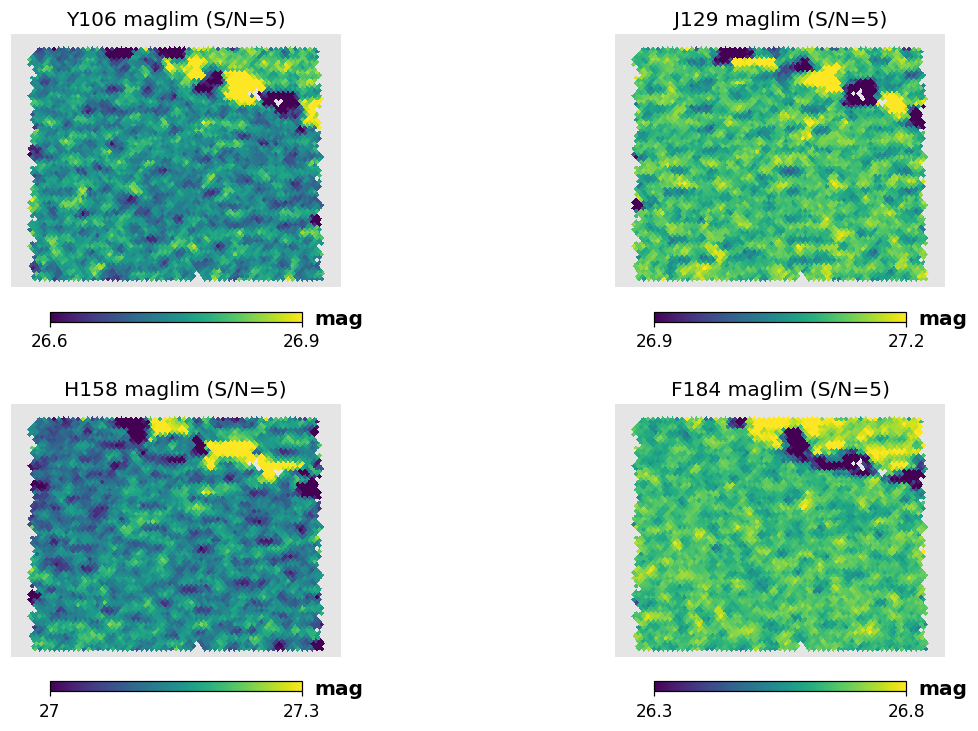

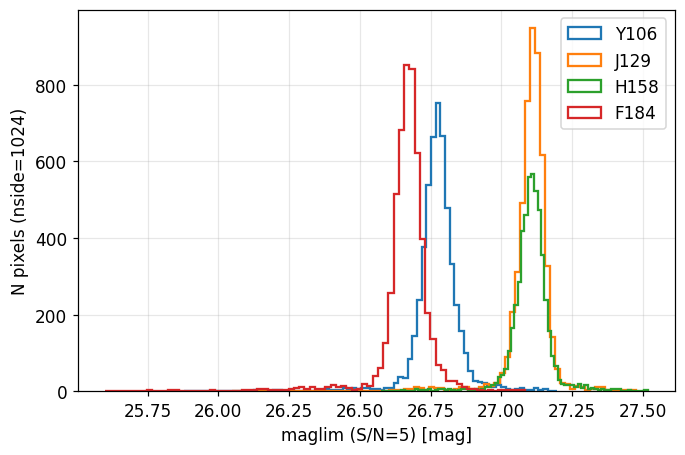

wrote roman_dc2_maglim_f106_nside1024.fits.gz (median 26.77)


wrote roman_dc2_maglim_f129_nside1024.fits.gz (median 27.11)


wrote roman_dc2_maglim_f158_nside1024.fits.gz (median 27.11)


wrote roman_dc2_maglim_f184_nside1024.fits.gz (median 26.67)


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, b in zip(axes.ravel(), BANDS):
    mlm = maglim_maps[b]
    cov = mlm != hp.UNSEEN
    vmin, vmax = np.percentile(mlm[cov], [2, 98])
    plt.axes(ax)
    hp.cartview(mlm, lonra=[50.5, 56.5], latra=[-42.3, -37.7], hold=True,
                title=f"{b} maglim (S/N={SNR_DEPTH})", unit="mag",
                min=vmin, max=vmax, badcolor="0.9")
fig.savefig(FIG_DIR / "maglim_maps.png", dpi=130, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
for b in BANDS:
    mlm = maglim_maps[b]
    ax.hist(mlm[mlm != hp.UNSEEN], bins=80, histtype="step", lw=1.5, label=b)
ax.set(xlabel=f"maglim (S/N={SNR_DEPTH}) [mag]", ylabel="N pixels (nside=1024)")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

OUT_DIR.mkdir(parents=True, exist_ok=True)
for b in BANDS:
    fb = "f" + b[1:]
    mlm = maglim_maps[b]
    cov = mlm != hp.UNSEEN
    fname = OUT_DIR / f"roman_dc2_maglim_{fb}_nside{NSIDE}.fits.gz"
    hp.write_map(fname, mlm, overwrite=True, dtype=np.float32)
    print(f"wrote {fname.name} (median {np.median(mlm[cov]):.2f})")


## 5. streamobs tables

Same formats as the LSST files in `data/others/` (these are what
`streamobs.surveys.SurveyFactory.set_completeness` / `set_photo_error` read):

- `roman_photoerror_f158.csv` — `# delta_mag,log_mag_err`, with
  `delta_mag = true mag − maglim` at the object's nside=1024 pixel and
  `log_mag_err` = log10 of the binned **truth-based scatter** ((p84−p16)/2 of
  observed − true) of star-classified objects. The reported SExtractor magerr is
  NOT used (it underestimates the true scatter ~2×); it is kept only as a
  comparison curve in the figure.
- `roman_stellar_efficiency_cutf158.csv` —
  `# mag_f158,delta_mag,detection_eff,classifiction_eff,classification_detection_eff`
  (the `classifiction_eff` typo is intentional: `set_completeness` looks that name up).
  `delta_mag` is keyed to the **median of the measured maglim map** (the maps and the
  tables share one internal convention; no renormalization is applied anywhere).
  Runtime maglim maps for other footprints (e.g. the HLWAS exptime-scaled map) should
  be expressed in this same convention, i.e. scaled relative to the DC2 depth.


reference maglim = measured map median = 27.107


wrote data/surveys/roman_hlwas/roman_photoerror_f158.csv  (148 rows, delta_mag -16.64 .. 1.36)
wrote data/surveys/roman_hlwas/roman_stellar_efficiency_cutf158.csv  (56 rows)


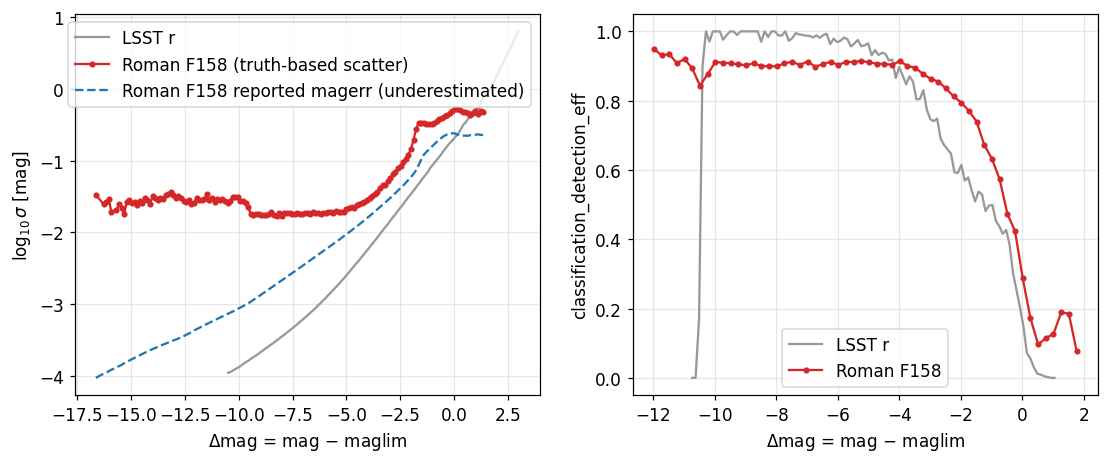

In [11]:
mlm = maglim_maps[BAND]
covered = mlm != hp.UNSEEN
MAGLIM_REF = float(np.median(mlm[covered]))   # tables keyed to the measured map median
print(f"reference maglim = measured map median = {MAGLIM_REF:.3f}")

# --- photoerror table -------------------------------------------------------
sel = (cat.matched & (cat.class_star > CLASS_STAR_CUT) & (cat["flags"] < FLAG_CUT))
pe = cat.loc[sel, ["alphawin_j2000", "deltawin_j2000", f"truth_mag_{BAND}",
                   f"mag_auto_{BAND}", f"magerr_auto_{BAND}"]].dropna()
pix = hp.ang2pix(NSIDE, pe.alphawin_j2000.values, pe.deltawin_j2000.values, lonlat=True)
ml_local = mlm[pix]
good = ml_local != hp.UNSEEN
delta = pe[f"truth_mag_{BAND}"].values[good] - ml_local[good]
# the error model is the TRUTH-BASED scatter of (observed - true): the reported
# SExtractor magerr underestimates it by ~2x (correlated noise in the coadds)
dm_obs = (pe[f"mag_auto_{BAND}"].values - pe[f"truth_mag_{BAND}"].values)[good]
logerr_reported = np.log10(pe[f"magerr_auto_{BAND}"].values[good])

dbins = np.arange(np.floor(delta.min() * 10) / 10, 1.5 + 1e-6, 0.12)
dmid = 0.5 * (dbins[1:] + dbins[:-1])
log_scatter = np.full(dmid.size, np.nan)
med_logerr_rep = np.full(dmid.size, np.nan)
ib = np.digitize(delta, dbins) - 1
for i in range(dmid.size):
    v = dm_obs[ib == i]
    if v.size >= 20:
        log_scatter[i] = np.log10((np.percentile(v, 84) - np.percentile(v, 16)) / 2)
        med_logerr_rep[i] = np.median(logerr_reported[ib == i])
keep = np.isfinite(log_scatter)

photoerr_tab = pd.DataFrame({"delta_mag": dmid[keep], "log_mag_err": log_scatter[keep]})
fpe = OUT_DIR / "roman_photoerror_f158.csv"
np.savetxt(fpe, photoerr_tab.values, delimiter=",", header="delta_mag,log_mag_err", fmt="%.6f")
print(f"wrote {fpe.relative_to(REPO)}  ({len(photoerr_tab)} rows, "
      f"delta_mag {photoerr_tab.delta_mag.min():.2f} .. {photoerr_tab.delta_mag.max():.2f})")

# --- stellar efficiency table ------------------------------------------------
eff_tab = pd.DataFrame({
    "mag_f158": MAG_MID,
    "delta_mag": MAG_MID - MAGLIM_REF,
    "detection_eff": eff_det,
    "classifiction_eff": eff_cls,
    "classification_detection_eff": eff_both,
})
eff_tab = eff_tab[n_all >= 20].fillna(0.0)
feff = OUT_DIR / "roman_stellar_efficiency_cutf158.csv"
np.savetxt(feff, eff_tab.values, delimiter=",",
           header="mag_f158,delta_mag,detection_eff,classifiction_eff,classification_detection_eff",
           fmt="%.6f")
print(f"wrote {feff.relative_to(REPO)}  ({len(eff_tab)} rows)")

# --- sanity overlay vs the LSST r-band tables --------------------------------
lsst_pe = np.genfromtxt(REPO / "data/others/lsst_photoerror_r.csv", delimiter=",", names=True)
lsst_eff = np.genfromtxt(REPO / "data/others/lsst_stellar_efficiency_cutr.csv", delimiter=",", names=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(lsst_pe["delta_mag"], lsst_pe["log_mag_err"], "-", color="0.6", label="LSST r")
axes[0].plot(photoerr_tab.delta_mag, photoerr_tab.log_mag_err, "C3o-", ms=3,
             label="Roman F158 (truth-based scatter)")
axes[0].plot(dmid[keep], med_logerr_rep[keep], "C0--", lw=1.5,
             label="Roman F158 reported magerr (underestimated)")
axes[0].set(xlabel=r"$\Delta$mag = mag $-$ maglim", ylabel=r"$\log_{10}\sigma$ [mag]")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(lsst_eff["delta_mag"], lsst_eff["classification_detection_eff"], "-", color="0.6", label="LSST r")
axes[1].plot(eff_tab.delta_mag, eff_tab.classification_detection_eff, "C3o-", ms=3, label="Roman F158")
axes[1].set(xlabel=r"$\Delta$mag = mag $-$ maglim", ylabel="classification_detection_eff")
axes[1].legend(); axes[1].grid(alpha=0.3)
fig.savefig(FIG_DIR / "lsst_comparison.png", dpi=130, bbox_inches="tight")
plt.show()


## Next steps

- Wire these into a `config/surveys/roman_hlwas.yaml` (mirroring `lsst_yr5.yaml`):
  `completeness: roman_stellar_efficiency_cutf158.csv`, `completeness_band: f158`,
  `log_photo_error: roman_photoerror_f158.csv`, `maglim_map_f158: roman_dc2_maglim_f158_nside1024.fits.gz`
  (or, for the full HLWAS footprint, a maglim map scaled from the exposure-time map —
  see `roman_hlwas_exptime_map.ipynb`; the DC2 map above characterizes the mock's depth).
- Caveats: the det→truth (detection-centric) match assigns a blended star to a single
  truth source, so the detection efficiency here is slightly conservative for blends;
  galaxy "size" is the measured `awin_world`, not a truth size.
